In [ ]:
!pip install -q kagglehub scikit-learn seaborn matplotlib

import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    print(f"✅ GPU Detected: {physical_devices[0]}")
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
else:
    print("⚠️ No GPU detected. Running on CPU.")

✅ GPU Detected: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


Using Colab cache for faster access to the 'cell-images-for-detecting-malaria' dataset.
Dataset location: /kaggle/input/cell-images-for-detecting-malaria/cell_images/cell_images
Total Images Available: 27560


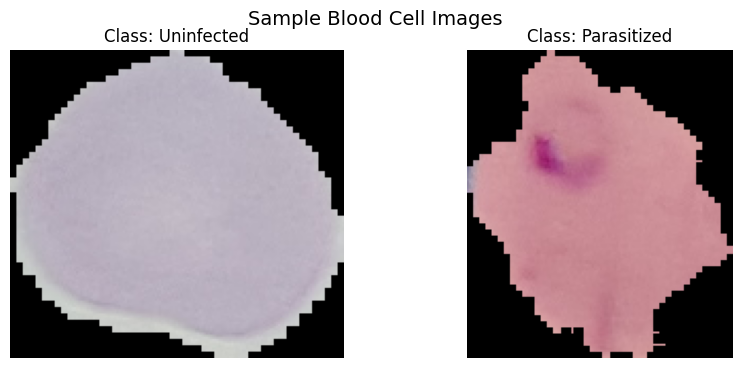

In [ ]:
import kagglehub

print("Downloading Kaggle Malaria Dataset")
dataset_path = kagglehub.dataset_download("iarunava/cell-images-for-detecting-malaria")
base_dir = os.path.join(dataset_path, 'cell_images', 'cell_images')
if not os.path.exists(base_dir):
    base_dir = os.path.join(dataset_path, 'cell_images')

classes = ['Uninfected', 'Parasitized']
print(f"Dataset location: {base_dir}")

total_images = sum(len(files) for _, _, files in os.walk(base_dir) if any(f.endswith('.png') for f in files))
print(f"Total Images Available: {total_images}")

plt.figure(figsize=(10, 4))
for i, cls in enumerate(classes):
    img_dir = os.path.join(base_dir, cls)
    img_name = [f for f in os.listdir(img_dir) if f.endswith('.png')][0]
    img_path = os.path.join(img_dir, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 2, i + 1)
    plt.imshow(img)
    plt.title(f"Class: {cls}")
    plt.axis('off')
plt.suptitle("Sample Blood Cell Images", fontsize=14)
plt.show()

In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

print("Loading and splitting dataset")
train_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

class_names = train_ds.class_names

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

normalization_layer = layers.Rescaling(1./255)

AUTOTUNE = tf.data.AUTOTUNE
def prepare_dataset(ds, augment=False):
    ds = ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    return ds.cache().prefetch(buffer_size=AUTOTUNE)

train_ds_prep = prepare_dataset(train_ds, augment=True)
val_ds_prep = prepare_dataset(val_ds)
test_ds_prep = prepare_dataset(test_ds)

print("Data Preprocessing & Splitting Complete.")

Loading and splitting dataset
Found 27558 files belonging to 2 classes.
Using 22047 files for training.
Found 27558 files belonging to 2 classes.
Using 5511 files for validation.
Data Preprocessing & Splitting Complete.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

y_train = np.concatenate([y for x, y in train_ds], axis=0)

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(weights))

print(f"Class Weights Calculated: {class_weights}")

Class Weights Calculated: {0: np.float64(0.9965196167058398), 1: np.float64(1.0035047792444243)}


In [ ]:
def build_model():
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=IMG_SIZE + (3,),
        include_top=False,
        weights='imagenet'
    )

    base_model.trainable = False

    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model, base_model

model, base_model = build_model()
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

EPOCHS = 10
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

y_train = np.concatenate([y for x, y in train_ds], axis=0)

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(weights))

print(f"Class Weights Calculated: {class_weights} (Defined within Cell 7)")

print("Starting Training...")
history = model.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)
print("Training Complete.")

Class Weights Calculated: {0: np.float64(0.9965196167058398), 1: np.float64(1.0035047792444243)} (Defined within Cell 7)
Starting Training...
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 187s 227ms/step - accuracy: 0.8809 - auc: 0.9461 - loss: 0.2957 - val_accuracy: 0.8764 - val_auc: 0.9701 - val_loss: 0.2830 - learning_rate: 0.0010
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9043 - auc: 0.9630 - loss: 0.2441 - val_accuracy: 0.8710 - val_auc: 0.9715 - val_loss: 0.2997 - learning_rate: 0.0010
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9118 - auc: 0.9674 - loss: 0.2285 - val_accuracy: 0.8833 - val_auc: 0.9706 - val_loss: 0.2868 - learning_rate: 0.0010
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9225 - auc: 0.9735 - loss: 0.2057 - val_accuracy: 0.9134 - val_auc: 0.9737 - val_loss: 0.2254 - learning_rate: 5.0000e-04
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9238 - auc: 0.9751 - loss: 0.1995 - val_accu

Evaluating on Test Set...
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.9132 - auc: 0.9767 - loss: 0.2128

Model Evaluation
Accuracy:  0.9132
ROC-AUC:   0.9767
Precision: 0.8819
Recall:    0.9606
F1-Score:  0.9196

Classification Report:
               precision    recall  f1-score   support

 Parasitized       0.95      0.86      0.91      1330
  Uninfected       0.88      0.96      0.92      1422

    accuracy                           0.91      2752
   macro avg       0.92      0.91      0.91      2752
weighted avg       0.92      0.91      0.91      2752



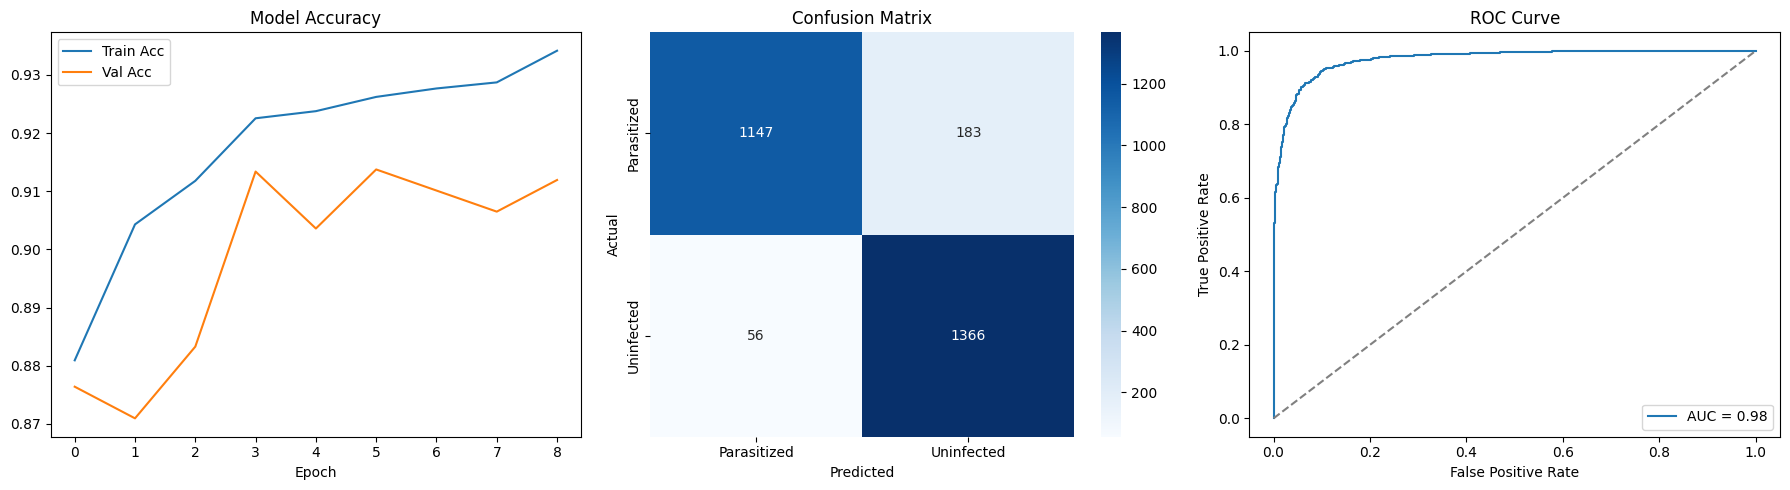

In [ ]:

print("Evaluating on Test Set...")
loss, test_acc, test_auc = model.evaluate(test_ds_prep)

y_true = []
y_pred_probs = []
for images, labels in test_ds_prep:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs).flatten()
y_pred = (y_pred_probs > 0.5).astype(int)

print("\nModel Evaluation")
print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_true, y_pred_probs):.4f}")
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
print(f"Precision: {precision:.4f}\nRecall:    {recall:.4f}\nF1-Score:  {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 3, 2)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1, 3, 3)
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
plt.plot(fpr, tpr, label=f'AUC = {test_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.tight_layout()
plt.show()

--- GENERATING HIGH-RESOLUTION CLINICAL GRAD-CAM ---


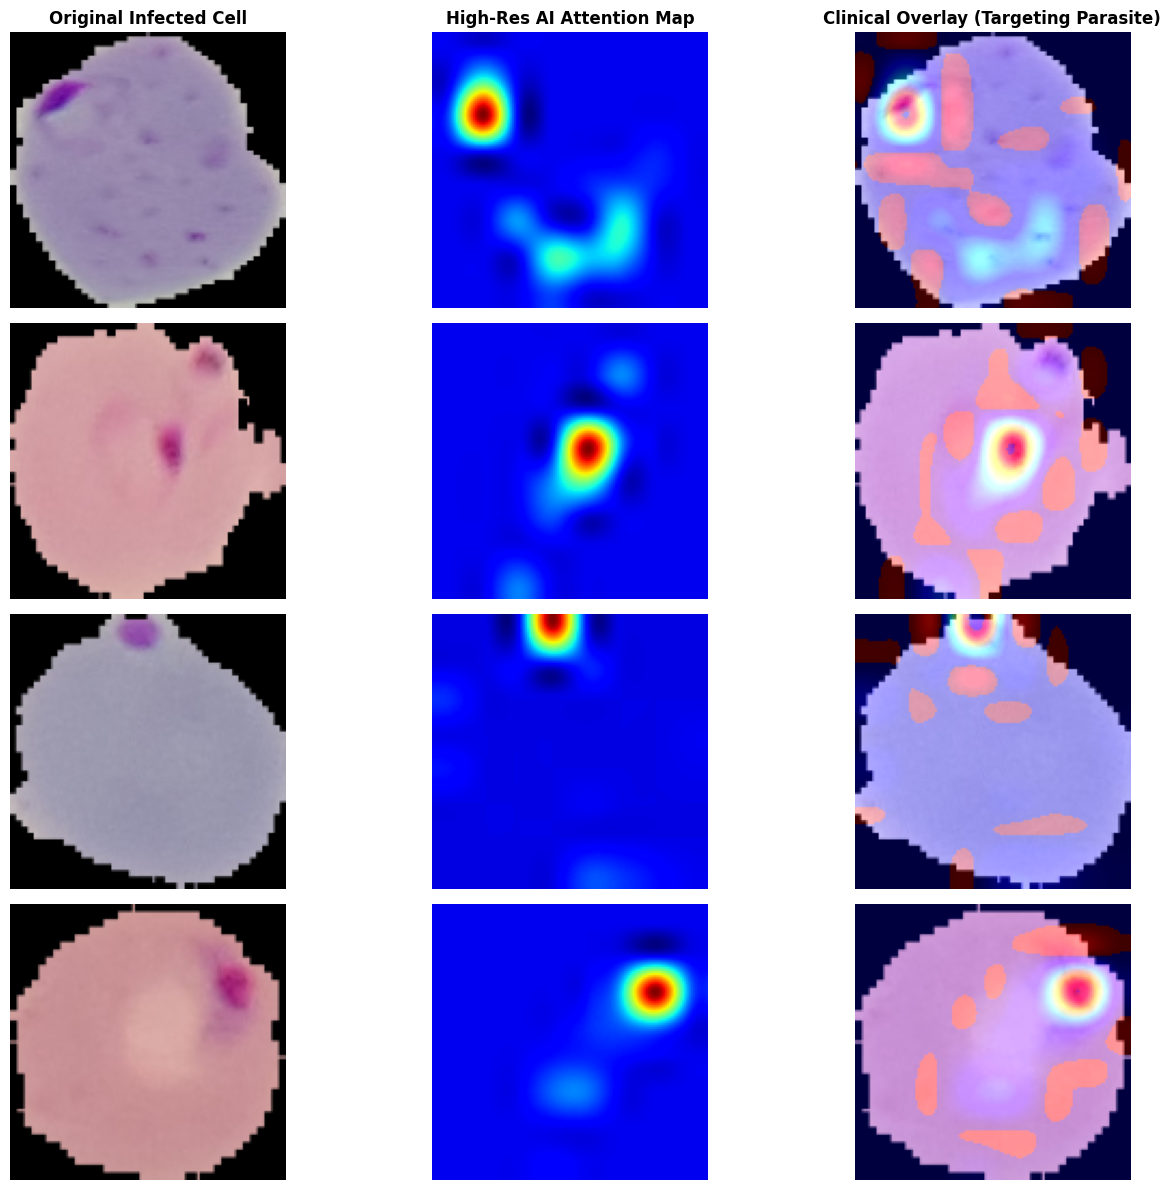

In [ ]:

import cv2

def make_gradcam_heatmap_binary(img_array, full_model, base_model, last_conv_layer_name, is_parasitized=True):
    conv_layer = base_model.get_layer(last_conv_layer_name)
    base_model_extractor = tf.keras.Model(
        inputs=base_model.inputs,
        outputs=[conv_layer.output, base_model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, base_output = base_model_extractor(img_array)
        tape.watch(last_conv_layer_output)
        x = base_output
        for layer in full_model.layers[2:]:
            if isinstance(layer, tf.keras.layers.Dropout):
                x = layer(x, training=False)
            else:
                x = layer(x)
        preds = x

        if is_parasitized:
            class_channel = 1.0 - preds[:, 0]
        else:
            class_channel = preds[:, 0]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.math.reduce_max(heatmap)
    if max_val != 0:
        heatmap = heatmap / max_val

    return heatmap.numpy()

def display_gradcam(img, heatmap, alpha=0.5):
    if np.max(img) > 1.0:
        img = img / 255.0

    heatmap_uint8 = np.uint8(255 * heatmap)
    jet = plt.colormaps.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_uint8]

    jet_heatmap = cv2.resize(jet_heatmap, (img.shape[1], img.shape[0]))

    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = np.clip(superimposed_img, 0, 1)
    return superimposed_img

print("--- GENERATING HIGH-RESOLUTION CLINICAL GRAD-CAM ---")

try:
    high_res_layer_name = 'block_13_expand_relu'
    base_model.get_layer(high_res_layer_name)
except:

    high_res_layer_name = base_model.layers[-20].name

target_idx = class_names.index('Parasitized')
infected_images = []
infected_labels = []

for images, labels in test_ds_prep:
    target_indices = np.where(labels.numpy() == target_idx)[0]
    for idx in target_indices:
        infected_images.append(images[idx])
        infected_labels.append(labels[idx])
        if len(infected_images) == 4:
            break
    if len(infected_images) == 4:
        break

plt.figure(figsize=(14, 12))

for i in range(4):
    img_tensor = infected_images[i]
    img_array = tf.expand_dims(img_tensor, axis=0)
    disp_img = img_tensor.numpy()

    heatmap = make_gradcam_heatmap_binary(
        img_array, model, base_model, high_res_layer_name, is_parasitized=True
    )

    heatmap_smoothed = cv2.resize(heatmap, (disp_img.shape[1], disp_img.shape[0]), interpolation=cv2.INTER_CUBIC)
    overlay = display_gradcam(disp_img, heatmap_smoothed)

    plt.subplot(4, 3, (i*3) + 1)
    plt.imshow(disp_img)
    if i == 0: plt.title("Original Infected Cell", fontweight='bold', fontsize=12)
    plt.axis('off')

    plt.subplot(4, 3, (i*3) + 2)
    plt.imshow(heatmap_smoothed, cmap='jet')
    if i == 0: plt.title("High-Res AI Attention Map", fontweight='bold', fontsize=12)
    plt.axis('off')

    plt.subplot(4, 3, (i*3) + 3)
    plt.imshow(overlay)
    if i == 0: plt.title("Clinical Overlay (Targeting Parasite)", fontweight='bold', fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:

def predict_with_confidence_warning(img_array, threshold=0.75):
    prob = model.predict(img_array, verbose=0)[0][0]
    predicted_class = 1 if prob > 0.5 else 0
    confidence = prob if predicted_class == 1 else 1 - prob

    status = "Confident"
    if confidence < threshold:
        status = "UNCERTAIN CASE – Needs Expert Review"

    return class_names[predicted_class], confidence, status

print("--- Simulated Clinical Prediction System ---")
pred_label, conf, status = predict_with_confidence_warning(img_array)
print(f"Prediction: {pred_label}")
print(f"Confidence Score: {conf:.2f}")
print(f"System Status: {status}")

model.save("biocon_malaria_mobilenetv2.h5")
print("\nModel saved successfully as 'biocon_malaria_mobilenetv2.h5'.")


--- Simulated Clinical Prediction System ---


Prediction: Parasitized
Confidence Score: 0.96
System Status: Confident

Model saved successfully as 'biocon_malaria_mobilenetv2.h5'.

PART A COMPLETE - SUMMARY OF SATISFIED REQUIREMENTS
1. Pretrained CNN used (MobileNetV2 - lightweight/fast).
2. Class Imbalance addressed via Scikit-Learn class weights.
3. Preprocessing implemented (Resizing, Normalization, Data Augmentation).
4. Interpretability satisfied via Grad-CAM visualizations.
5. Clinical application satisfied via the Uncertainty Warning System.



In [ ]:

from sklearn.ensemble import RandomForestClassifier

feature_extractor = tf.keras.Model(
    inputs=model.inputs,
    outputs=model.layers[-3].output
)

def extract_features(dataset):
    features, labels = [], []
    for imgs, lbls in dataset:
        feats = feature_extractor.predict(imgs, verbose=0)
        features.extend(feats)
        labels.extend(lbls.numpy())
    return np.array(features), np.array(labels)

print("Extracting features from training set")
X_train_rf, y_train_rf = extract_features(train_ds_prep)
print("Extracting features from test set")
X_test_rf, y_test_rf = extract_features(test_ds_prep)

print("Training Random Forest Classifier on CNN features")
rf_model = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1, class_weight='balanced')
rf_model.fit(X_train_rf, y_train_rf)

rf_preds = rf_model.predict(X_test_rf)
rf_acc = accuracy_score(y_test_rf, rf_preds)

print("\nHybrid Model Results")
print(f"Random Forest Accuracy: {rf_acc:.4f}")
print("Classification Report:\n", classification_report(y_test_rf, rf_preds, target_names=class_names))


Extracting features from training set
Extracting features from test set
Training Random Forest Classifier on CNN features

Hybrid Model Results
Random Forest Accuracy: 0.9121
Classification Report:
               precision    recall  f1-score   support

 Parasitized       0.96      0.85      0.90      1330
  Uninfected       0.87      0.97      0.92      1422

    accuracy                           0.91      2752
   macro avg       0.92      0.91      0.91      2752
weighted avg       0.92      0.91      0.91      2752



In [ ]:

print("\nClinical Parasite Density Calculator")

def generate_patient_report(dataset, patient_id="BIO-9921"):
    total_cells = 0
    infected_count = 0
    confidence_scores = []

    print(f"Analyzing Slide for Patient: {patient_id}...")

    for imgs, lbls in dataset.take(5):
        preds = model.predict(imgs, verbose=0)
        for p in preds:
            total_cells += 1
            if p > 0.5:
                infected_count += 1
                confidence_scores.append(p[0])
            else:
                confidence_scores.append(1 - p[0])

    parasitemia_index = (infected_count / total_cells) * 100
    avg_confidence = np.mean(confidence_scores) * 100

    if parasitemia_index == 0:
        severity = "NIL (Healthy)"
    elif parasitemia_index < 1.0:
        severity = "LOW (Monitor Patient)"
    elif parasitemia_index < 5.0:
        severity = "MODERATE (Immediate Treatment Required)"
    else:
        severity = "HIGH (Critical/Emergency)"

    print("\n" + "="*40)
    print(f" BIOCON LTD. AUTOMATED BIOPSY REPORT ")
    print("="*40)
    print(f"Patient ID:        {patient_id}")
    print(f"Total Cells Scanned: {total_cells}")
    print(f"Infected RBCs:      {infected_count}")
    print(f"Parasitemia Index:  {parasitemia_index:.2f}%")
    print(f"Diagnostic Result:  {'POSITIVE' if infected_count > 0 else 'NEGATIVE'}")
    print(f"Severity Grade:     {severity}")
    print(f"AI System Confidence: {avg_confidence:.2f}%")
    print("="*40)

generate_patient_report(test_ds_prep)


Clinical Parasite Density Calculator
Analyzing Slide for Patient: BIO-9921...

 BIOCON LTD. AUTOMATED BIOPSY REPORT 
Patient ID:        BIO-9921
Total Cells Scanned: 160
Infected RBCs:      97
Parasitemia Index:  60.62%
Diagnostic Result:  POSITIVE
Severity Grade:     HIGH (Critical/Emergency)
AI System Confidence: 93.04%
